# 🟡 Lesson 06 — GeoPandas

**Level: Intermediate** · Pandas + geometry: shapefiles, GeoJSON, spatial joins and quick maps for GIS work without a GUI.

*Part of the companion package for [python_for_geologists](https://github.com/kevinalexandr19/python_for_geologists) by Kevin Alexander Gomez.*

In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

DATA = Path("..") / "data"
print("geopandas", gpd.__version__)

geopandas 1.1.3


## 1. Build a GeoDataFrame from a plain CSV
The earthquake catalogue has lat/lon columns — that is all we need.

In [2]:
q = pd.read_csv(DATA / "earthquakes.csv")
q.columns = ["date", "time", "lat", "lon", "depth_km", "magnitude"]

gdf = gpd.GeoDataFrame(q, geometry=gpd.points_from_xy(q["lon"], q["lat"]), crs="EPSG:4326")
print(len(gdf), "earthquakes | CRS:", gdf.crs)
gdf.head(3)

18933 earthquakes | CRS: EPSG:4326


,date,time,lat,lon,depth_km,magnitude,geometry
0,13/01/1960,15:40:34.00,-16.145,-72.144,60,7.5,POINT (-72.144 -16.145)
1,15/01/1960,09:30:24.00,-15.000,-75.000,70,7.0,POINT (-75 -15)
2,17/01/1960,02:57:58.00,-14.500,-74.500,150,6.4,POINT (-74.5 -14.5)


## 2. Spatial attributes and filtering

In [3]:
big = gdf[gdf["magnitude"] >= 7.0]
print(f"{len(big)} events with M >= 7.0")
print("bounding box of catalogue:", gdf.total_bounds.round(2))

32 events with M >= 7.0
bounding box of catalogue: [-82.26 -16.7  -68.67  -3.58]


## 3. Reproject — degrees to metres (UTM 18S covers most of Peru)

In [4]:
utm = gdf.to_crs("EPSG:32718")
print("new CRS:", utm.crs.name)
print("first point (m):", utm.geometry.iloc[0])

new CRS: WGS 84 / UTM zone 18S
first point (m): POINT (805454.2513503683 8212907.237543183)


## 4. Quick map

Text(42.847222222222214, 0.5, 'lat')

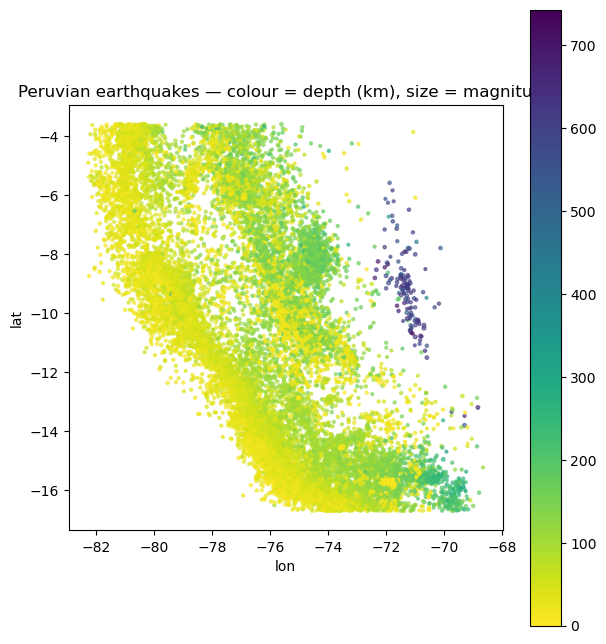

In [5]:
ax = gdf.plot(column="depth_km", markersize=gdf["magnitude"], cmap="viridis_r",
              legend=True, figsize=(7, 8), alpha=0.6)
ax.set_title("Peruvian earthquakes — colour = depth (km), size = magnitude")
ax.set_xlabel("lon"); ax.set_ylabel("lat")

## 5. Buffer and spatial query — events near a city
Buffers must be done in a metric CRS, never in degrees.

In [6]:
from shapely.geometry import Point

lima = gpd.GeoSeries([Point(-77.03, -12.05)], crs="EPSG:4326").to_crs("EPSG:32718")
zone = lima.buffer(200_000)                       # 200 km radius
near = utm[utm.within(zone.iloc[0])]
print(f"{len(near)} earthquakes within 200 km of Lima")
print("strongest:", near["magnitude"].max())

2194 earthquakes within 200 km of Lima
strongest: 8.0


## 6. Save to GIS formats

In [7]:
out = Path("outputs"); out.mkdir(exist_ok=True)
big.to_file(out / "earthquakes_M7plus.geojson", driver="GeoJSON")
print("saved", len(big), "features ->", out / "earthquakes_M7plus.geojson")

saved 32 features -> outputs\earthquakes_M7plus.geojson


### ✏️ Try it
1. Repeat the buffer query for Arequipa (-71.54, -16.41) with a 150 km radius.
2. Save only events deeper than 300 km to a GeoPackage (`driver='GPKG'`).

📚 Docs: https://geopandas.org/en/stable/